# Information Leakage and the Asymmetric Quantum Cloning Region

This notebook contains the **main numerical study developed for the Master's Thesis**. It connects the information-leakage framework explored in the previous notebooks with the feasible region of an asymmetric \(1\!\to\!2\) quantum cloning attack on BB84.

The analysis has four objectives:

1. construct the optimal boundary of the asymmetric cloning region for qubits;
2. map each feasible pair \((p_1,p_2)\) to a disturbance parameter for Bob and an information-leakage value for Eve;
3. study how an additional depolarizing-noise parameter changes both quantities; and
4. compare the resulting leakage with the effective Alice--Bob channel capacity, including the usual \(11\%\) QBER reference point.

Here, \(p_1\) describes the quality of the clone delivered to Bob and \(p_2\) the quality of Eve's clone. The notebook follows the model and conventions used in the thesis.

> **Repository context.** The first two notebooks document preliminary investigations that were useful during the development of the thesis but were not included in the final manuscript. This notebook contains the substantially more complete analysis that motivated the final results.

The comparison introduced later between Alice--Bob channel capacity and Eve's leakage should be interpreted as a **model-specific diagnostic quantity**, not as a replacement for a complete QKD secret-key-rate proof.

In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt

## 1. Optimal asymmetric cloning region

For the asymmetric \(1 \to 2\) cloning model, not every pair \((p_1,p_2)\) is physically achievable. The thesis uses the boundary of the admissible cloning region, defined by

$$
\|p\|_Q = 1,
$$

where \(p=(p_1,p_2)\). Restricting the calculation to the first quadrant is sufficient because the clone-quality parameters considered here are non-negative.

The boundary is parameterized radially as

$$
p_1 = R\cos\theta,\qquad p_2 = R\sin\theta,\qquad 0\leq\theta\leq\frac{\pi}{2}.
$$

Because the adopted \(Q\)-norm expression is homogeneous in \(p_1\) and \(p_2\), the radius \(R\) can be obtained directly from the norm of the unit direction. This gives a dense numerical representation of the optimal trade-off between Bob's and Eve's clone qualities.

In [2]:
def optimal_cloning_region(d, num_points=200):
    """
    Sample the boundary of the optimal asymmetric 1 -> 2 cloning region
    defined by ||p||_Q = 1.

    Parameters
    ----------
    d : int
        Hilbert-space dimension.
    num_points : int, optional
        Number of boundary points.

    Returns
    -------
    p1s, p2s : np.ndarray
        Clone-quality parameters along the first-quadrant boundary.
    """
    thetas = np.linspace(0, np.pi / 2, num_points)

    cos_t = np.cos(thetas)
    sin_t = np.sin(thetas)

    # Q-norm of each unit radial direction.
    sum_terms = cos_t + sin_t
    diff_terms_sq = (cos_t - sin_t) ** 2
    cross_terms = cos_t * sin_t

    sqrt_part = np.sqrt(d**2 * diff_terms_sq + 4 * cross_terms)
    lambda_max_part = 0.5 * d * (d * sum_terms + sqrt_part)
    norm_at_unit_R = (lambda_max_part - sum_terms) / (d**2 - 1)

    # Homogeneity gives the radius at which ||p||_Q = 1.
    R = 1.0 / norm_at_unit_R

    p1s = R * cos_t
    p2s = R * sin_t

    return p1s, p2s

In [3]:
p1s, p2s = optimal_cloning_region(num_points=1000, d=2)

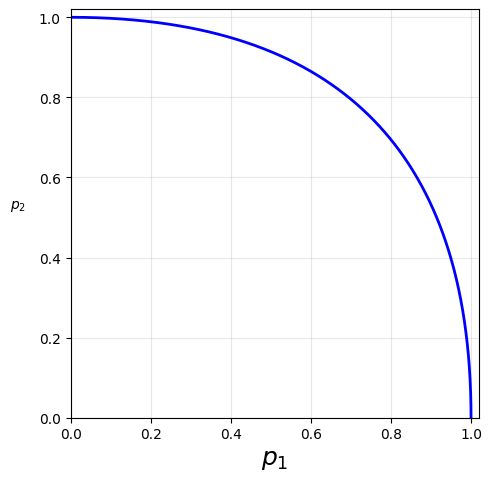

In [4]:
plt.figure(figsize=(5, 5))


plt.plot(
    p1s,
    p2s,
    color="blue",
    linewidth=2,
)

plt.xlabel(r"$p_1$", fontsize=18)
plt.ylabel(r"$p_2$",rotation=0, labelpad=15)

plt.xlim(0, 1.02)
plt.ylim(0, 1.02)
plt.grid(alpha=0.3)
plt.gca().set_aspect("equal", adjustable="box")


plt.tight_layout()
plt.show()

The two extremes have the expected interpretation: improving Bob's clone forces Eve's clone to degrade, and vice versa. The remainder of the notebook evaluates information leakage and disturbance **along this optimal boundary**, rather than choosing arbitrary \((p_1,p_2)\) pairs.

## 2. From the cloning boundary to leakage and disturbance

For a qubit depolarizing map of the form

$$
T_i(\rho)=p_i\rho+(1-p_i)\frac{I}{2},
$$

the disturbance observed on Bob's branch is represented by

$$
\alpha=\frac{1-p_1}{2}.
$$

Within the BB84 setting used here, this quantity coincides with the induced bit-error probability in the matched basis.

Eve's leakage is evaluated with the leakage expression adopted in the thesis,

$$
L_E=\log_2\left[(1-p_2)+p_2\,2^{Q_{\mathrm{BB84}}}\right].
$$

For \(Q_{\mathrm{BB84}}=1\), this reduces to

$$
L_E=\log_2(1+p_2).
$$

Mapping the cloning-region boundary through these two expressions produces the leakage--disturbance curve used in the subsequent analysis.

In [5]:
colors = plt.cm.tab10(np.linspace(0, 1, 7))

In [6]:
def compute_cloning_leakage_alpha(p1s, p2s, pc=0.0, Q_bb84=1.0):
    """
    Computes alpha (gentleness) and leakage for cloning-based attack,
    with optional depolarizing noise.

    Parameters
    ----------
    p1s : array-like
        Quality parameters for Bob's clone.
    p2s : array-like
        Quality parameters for Eve's clone.
    pc : float
        Depolarizing channel parameter (0 = no noise).
    Q_bb84 : float
        Maximal leakage (BB84 -> typically 1).

    Returns
    -------
    alphas_cloning : np.ndarray
    leakages_cloning : np.ndarray
    """

    p1s = np.asarray(p1s)
    p2s = np.asarray(p2s)

    alphas_cloning = []
    leakages_cloning = []

    for i in range(len(p1s)):

        # --- Apply depolarizing noise (you can change this later) ---
        p1_eff = (1 - pc) * p1s[i]
        p2_eff = (1 - pc) * p2s[i]

        # --- Alpha (gentleness) ---
        alpha_gentle = (1 - p1_eff) / 2

        # --- Leakage ---
        leakage = np.log2((1 - p2_eff) + p2_eff * 2**Q_bb84)
        alphas_cloning.append(alpha_gentle)
        leakages_cloning.append(leakage)

    return np.array(alphas_cloning), np.array(leakages_cloning)

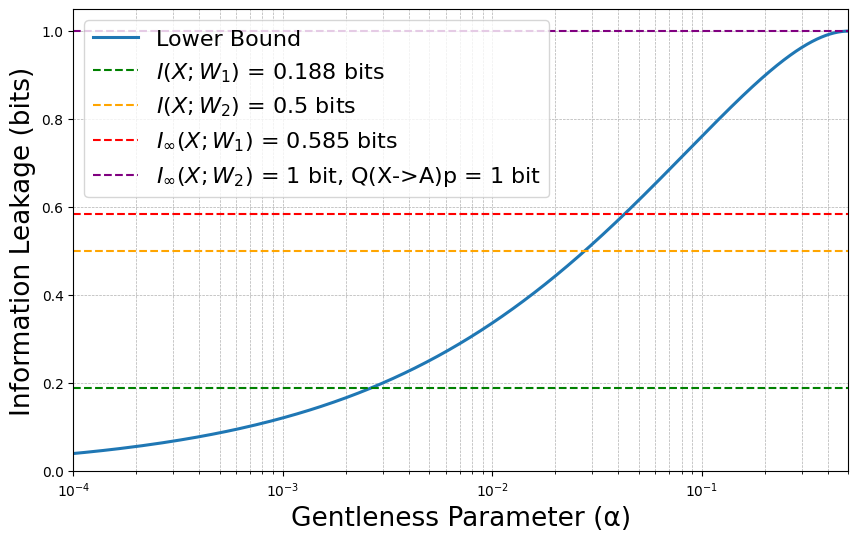

In [7]:
alphas_cloning_1, leakages_cloning_1 = compute_cloning_leakage_alpha(p1s, p2s)

plt.figure(figsize=(10, 6))
plt.plot(alphas_cloning_1, leakages_cloning_1, markersize=2,linewidth=2.2 ,color = colors[0] ,label='Lower Bound')

plt.axhline(y=0.188, color='green', linestyle='--', label='$I(X;W_{1})$ = 0.188 bits')
plt.axhline(y=0.5, color='orange', linestyle='--', label='$I(X;W_{2})$ = 0.5 bits')
plt.axhline(y=0.585, color='red', linestyle='--', label='$I_{\\infty}(X;W_{1})$ = 0.585 bits')

# Combine the lines that are equal to 1.0
plt.axhline(y=1.0, color='purple', linestyle='--', label='$I_{\\infty}(X;W_{2})$ = 1 bit, Q(X->A)p = 1 bit')

# Setting the x-axis to a logarithmic scale
plt.xscale('log')

# Limiting the x-axis to the range 10^-4 to 10^0
plt.xlim(1e-4, 0.5)

plt.ylim(0, 1.05)

# Title and labels
plt.xlabel('Gentleness Parameter (α)',fontsize = 19)
plt.ylabel('Information Leakage (bits)',fontsize = 19)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend(fontsize=16)
plt.show()

The horizontal reference lines reproduce the information values used during the earlier stages of the study. The cloning construction is more systematic than the hand-selected POVMs of Notebook 2: rather than testing isolated measurement families, it explores the optimal trade-off allowed by the adopted cloning region.

## 3. Effect of additional depolarizing noise

The next experiment introduces an additional depolarizing parameter \(p_c\). In this model, both clone-quality parameters are scaled as

$$
p_i^{\mathrm{eff}}=(1-p_c)p_i.
$$

Consequently,

$$
\alpha(p_c)=\frac{1-(1-p_c)p_1}{2},
$$

while Eve's leakage becomes

$$
L_E(p_c)=\log_2\left[1+(1-p_c)p_2\right].
$$

Sweeping \(p_c\) therefore shows how the leakage--disturbance boundary moves as the effective copies are degraded.

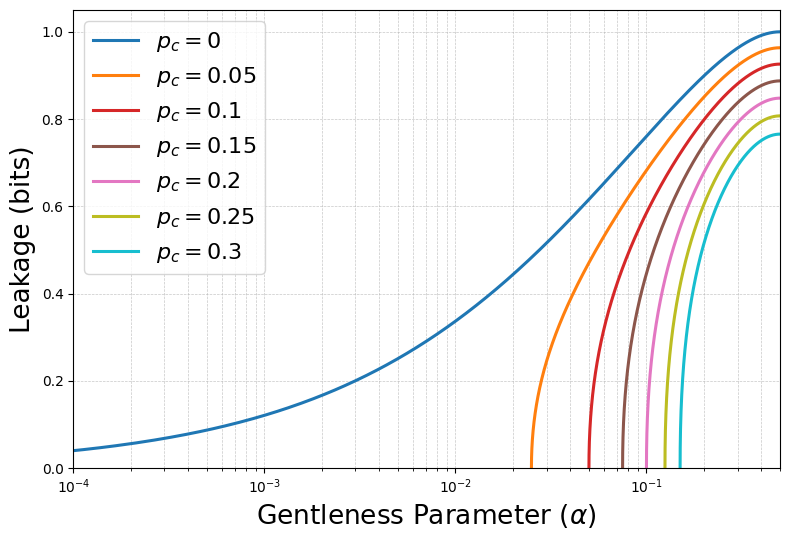

In [8]:
# Values of depolarizing noise
pcs = [0,0.05, 0.1, 0.15, 0.2, 0.25, 0.3]


# Colors (clear and distinguishable)
colors = plt.cm.tab10(np.linspace(0, 1, len(pcs)))

plt.figure(figsize=(8, 5.5))

for pc, color in zip(pcs, colors):
    alphas, leakages = compute_cloning_leakage_alpha(
        p1s,
        p2s,
        pc=pc
    )

    # Sort for clean curve
    idx = np.argsort(alphas)
    alphas = alphas[idx]
    leakages = leakages[idx]

    # Avoid log(0)
#    mask = alphas > 0
#    alphas = alphas[mask]
#    leakages = leakages[mask]

    plt.plot(
        alphas,
        leakages,
        linewidth=2.2,
        color=color,
        label=fr"$p_c={pc}$"
    )

# Axes
plt.xscale("log")
plt.xlim(1e-4, 0.5)
plt.ylim(0, 1.05)

plt.xlabel(r"Gentleness Parameter ($\alpha$)",fontsize = 19)
plt.ylabel("Leakage (bits)",fontsize = 19)

plt.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.7)

plt.legend(fontsize=16)
plt.tight_layout()
plt.show()

## 4. Alice--Bob channel capacity and Eve's leakage

To study the same trade-off from an information-transmission perspective, the sifted Alice--Bob link is modeled as a binary symmetric channel (BSC).

For a crossover probability \(q\),

$$
C_{\mathrm{BSC}}(q)=1-h_2(q),
$$

with

$$
h_2(q)=-q\log_2q-(1-q)\log_2(1-q).
$$

Using Bob's effective clone parameter,

$$
q(p_c)=\frac{1-(1-p_c)p_1}{2},
$$

the corresponding Alice--Bob capacity is

$$
C_{AB}(p_c)=1-h_2\left(\frac{1-(1-p_c)p_1}{2}\right).
$$

For Eve,

$$
L_E(p_c)=\log_2\left[1+(1-p_c)p_2\right].
$$

Two complementary comparisons are useful:

$$
\Delta C_{AB}(p_c)=C_{AB}(0)-C_{AB}(p_c),
$$

which measures how much useful Alice--Bob capacity is lost, and

$$
\Delta L_E(p_c)=L_E(0)-L_E(p_c),
$$

which measures how much Eve's leakage is reduced.

We also define the diagnostic difference

$$
\Delta_{\mathrm{info}}(p_c)=C_{AB}(p_c)-L_E(p_c).
$$

Positive values mean that the BSC capacity is numerically larger than the leakage assigned to Eve by this model; negative values mean the opposite.

> **Interpretation caveat.** \(C_{AB}\) is a Shannon channel-capacity quantity, while \(L_E\) is the leakage metric used for Eve. Their difference is therefore a comparative diagnostic used in this study, **not an operational secret-key rate or a standalone security proof**. The added-noise model likewise assumes that the same effective depolarizing factor is applied to both branches; conclusions below are conditional on that model.

In [9]:
def binary_entropy(q: float) -> float:
    """
    Binary entropy h2(q) in bits.

    h2(q) = -q log2 q - (1-q) log2 (1-q)

    By continuity:
        h2(0) = h2(1) = 0

    Parameters
    ----------
    q : float
        Probability in [0, 1].

    Returns
    -------
    float
        Binary entropy in bits.
    """
    if not (0.0 <= q <= 1.0):
        raise ValueError(f"q must be in [0,1], got {q}")

    if q == 0.0 or q == 1.0:
        return 0.0

    return -q * math.log2(q) - (1.0 - q) * math.log2(1.0 - q)

In [10]:
def bsc_capacity(q: float) -> float:
    """
    Capacity of a Binary Symmetric Channel (BSC) with crossover q.

    C(q) = 1 - h2(q)

    Parameters
    ----------
    q : float
        BER / crossover probability in [0, 1].

    Returns
    -------
    float
        Channel capacity in bits per channel use.
    """
    return 1.0 - binary_entropy(q)


In [11]:
def ber_from_p1(p1: float) -> float:
    return (1-p1)/2

def leakage_from_p2(p2: float, Q_bb84 = 1) -> float:
    return np.log2((1 - p2) + p2 * 2**Q_bb84)

In [12]:
def effective_clone_parameter(p: float, pc: float) -> float:
    """
    Effective clone parameter after additional trusted depolarizing noise.

    If
        T(rho) = p rho + (1-p) I/2
    and
        D_pc(rho) = (1-pc) rho + pc I/2
    then
        D_pc(T(rho)) = p' rho + (1-p') I/2
    with
        p' = (1-pc) p

    Parameters
    ----------
    p : float
        Original clone parameter in [0,1].
    pc : float
        Added depolarizing noise coefficient in [0,1].

    Returns
    -------
    float
        Effective parameter p' in [0,1].
    """
    if not (0.0 <= p <= 1.0):
        raise ValueError(f"p must be in [0,1], got {p}")
    if not (0.0 <= pc <= 1.0):
        raise ValueError(f"pc must be in [0,1], got {pc}")

    return (1.0 - pc) * p

In [13]:
def alice_bob_capacity(p1: float, pc: float = 0.0) -> float:
    """
    Alice-Bob channel capacity under added trusted depolarizing noise.

        p1' = (1-pc) p1
        q(pc) = (1 - p1')/2
        C_AB(pc) = 1 - h2(q(pc))
    """
    p1_eff = effective_clone_parameter(p1,pc)
    q = ber_from_p1(p1_eff)
    return bsc_capacity(q)

### 4.1 Capacity loss on the Alice--Bob branch

In [14]:
pcs = [0,0.05, 0.1, 0.15, 0.2, 0.25, 0.3]

In [15]:
def delta_capacity_loss(p1: float, pc: float) -> float:
    """
    Capacity loss suffered by Alice-Bob due to added noise:

        ΔC_AB(pc) = C_AB(0) - C_AB(pc)
    """
    return alice_bob_capacity(p1, 0.0) - alice_bob_capacity(p1, pc)

In [16]:
d_c_losses = {}
for pc in pcs:
    results = []
    for p1 in p1s:
        cap_loss = delta_capacity_loss(p1,pc)
        results.append(cap_loss)
    d_c_losses[f"{pc}"] = results



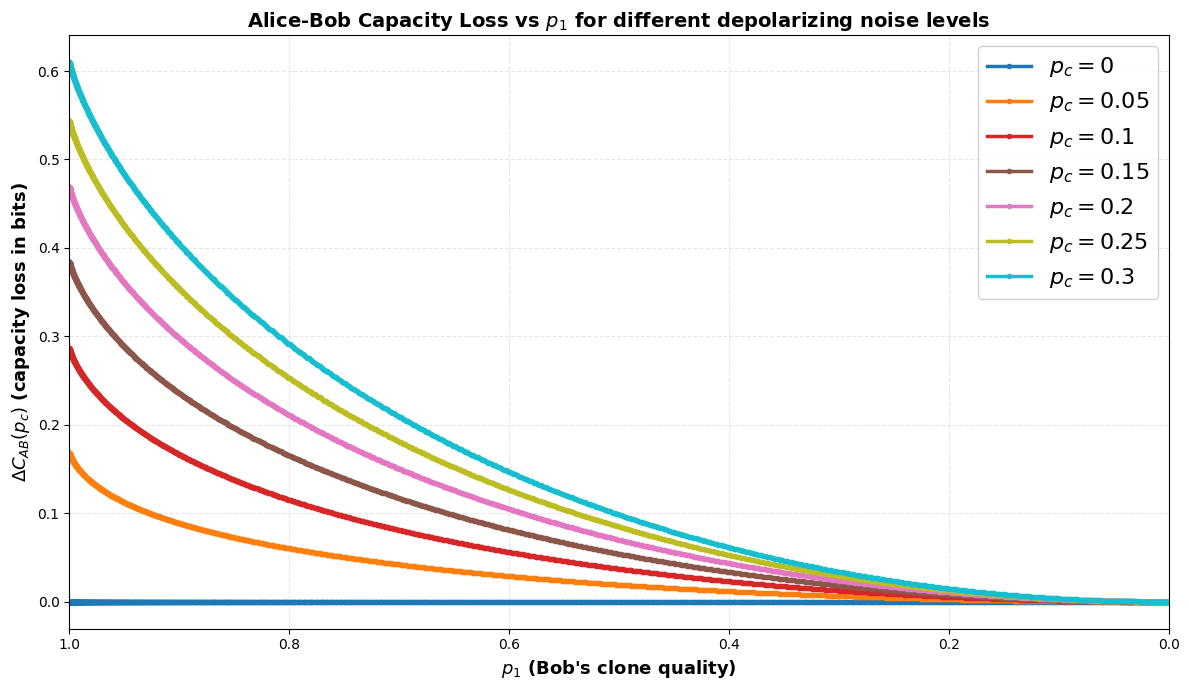

In [17]:
plt.figure(figsize=(12, 7))

# Use a colormap for distinct colors
colors_map = plt.cm.tab10(np.linspace(0, 1, len(pcs)))

for idx, pc in enumerate(pcs):
    losses = d_c_losses[f"{pc}"]
    plt.plot(
        p1s,
        losses,
        linewidth=2.5,
        marker='o',
        markersize=3,
        color=colors_map[idx],
        label=fr"$p_c = {pc}$"
    )

plt.xlabel(r"$p_1$ (Bob's clone quality)", fontsize=13, fontweight='bold')
plt.ylabel(r"$\Delta C_{AB}(p_c)$ (capacity loss in bits)", fontsize=13, fontweight='bold')
plt.title(r"Alice-Bob Capacity Loss vs $p_1$ for different depolarizing noise levels", fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(loc='best', fontsize=16, framealpha=0.9)
plt.xlim(p1s[0], p1s[-1])
plt.tight_layout()
plt.show()

### 4.2 Leakage reduction on Eve's branch

In [18]:
def delta_eve_leakage_reduction(p2: float, pc: float) -> float:
    """
    Leakage reduction suffered by Eve due to added noise:

        ΔL_E(pc) = L_E(0) - L_E(pc)
    """
    p2_eff = effective_clone_parameter(p = p2, pc = pc)
    return leakage_from_p2(p2) - leakage_from_p2(p2_eff)

In [19]:
d_e_leakages = {}
for pc in pcs:
    results = []
    for p2 in p2s:
        leakage_red = delta_eve_leakage_reduction(p2, pc)
        results.append(leakage_red)
    d_e_leakages[f"{pc}"] = results


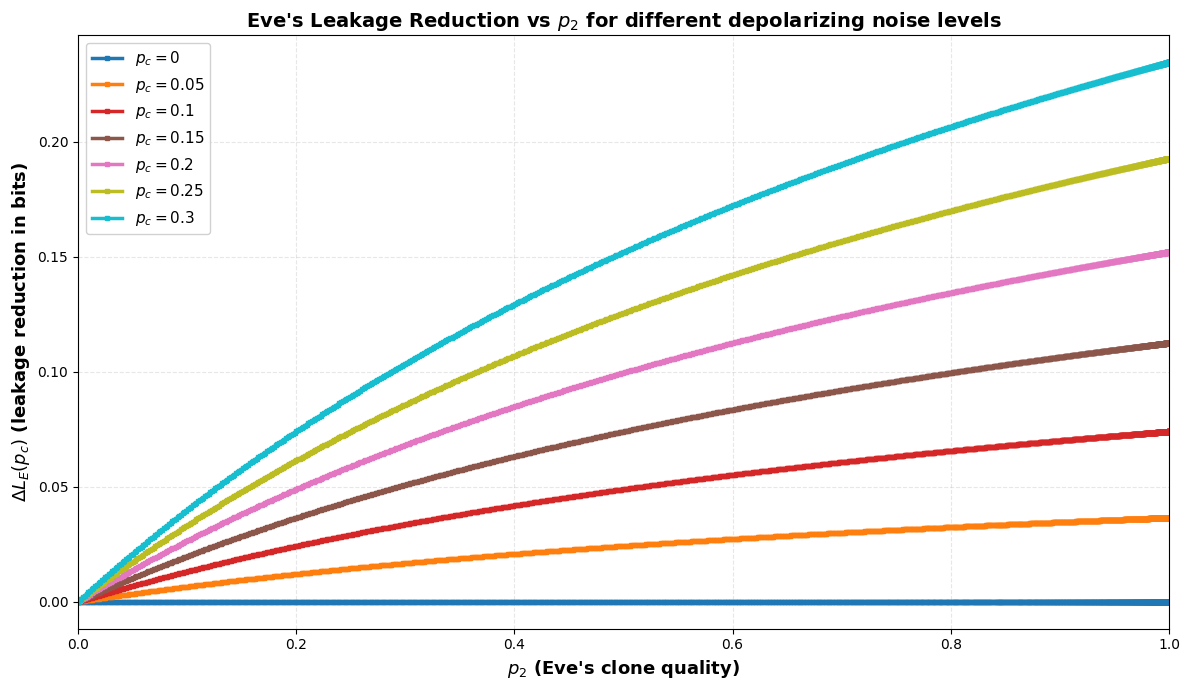

In [20]:
plt.figure(figsize=(12, 7))

# Use a colormap for distinct colors
colors_map = plt.cm.tab10(np.linspace(0, 1, len(pcs)))

for idx, pc in enumerate(pcs):
    leakages = d_e_leakages[f"{pc}"]
    plt.plot(
        p2s,
        leakages,
        linewidth=2.5,
        marker='s',
        markersize=3,
        color=colors_map[idx],
        label=fr"$p_c = {pc}$"
    )

plt.xlabel(r"$p_2$ (Eve's clone quality)", fontsize=13, fontweight='bold')
plt.ylabel(r"$\Delta L_E(p_c)$ (leakage reduction in bits)", fontsize=13, fontweight='bold')
plt.title(r"Eve's Leakage Reduction vs $p_2$ for different depolarizing noise levels", fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(loc='best', fontsize=11, framealpha=0.9)
plt.xlim(p2s[0], p2s[-1])
plt.tight_layout()
plt.show()

### 4.3 Direct comparison along the cloning boundary

The cloning boundary is stored from the Bob-favoured extreme $(p_1 \approx 1, p_2 \approx 0)$ towards the Eve-favoured extreme $(p_1 \approx 0, p_2 \approx 1)$. Each point in the following plots therefore represents one physically linked pair $(p_1, p_2)$; the two parameters must not be varied independently when interpreting the boundary.

In [21]:
def informational_advantage(p1: float, p2: float, pc: float = 0.0) -> float:
    """
    Net Alice-Bob advantage over Eve:

        Delta_info(pc) = C_AB(pc) - L_E(pc)

    Positive values mean Alice-Bob retain more useful information
    than Eve gets, according to this model.
    """
    p2_eff = effective_clone_parameter(p2,pc)
    return alice_bob_capacity(p1, pc) - leakage_from_p2(p2_eff)

In [22]:
inf_adv = {}
for pc in pcs: 
    results = []   
    for i in range(len(p2s)):
        result = informational_advantage(p1s[i], p2s[i], pc)
        results.append(result)
        
    inf_adv[f"{pc}"] = results


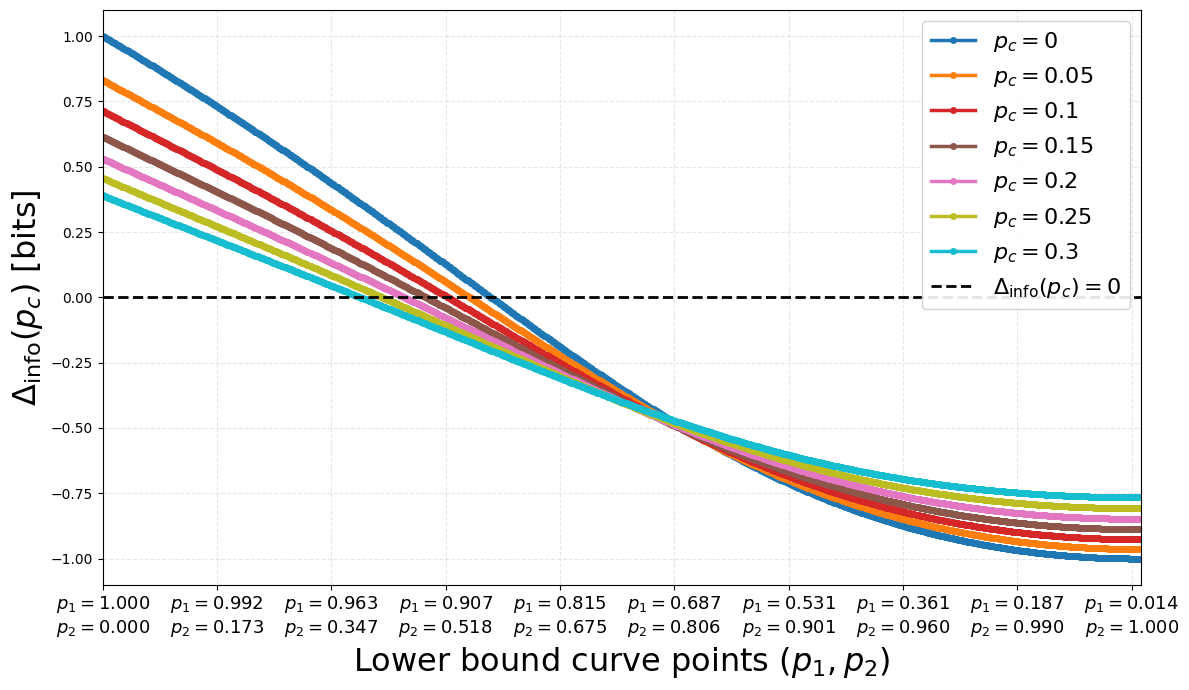

In [23]:
plt.figure(figsize=(12, 7))

# Use a colormap for distinct colors
colors_map = plt.cm.tab10(np.linspace(0, 1, len(pcs)))

x = np.arange(len(p1s))

for idx, pc in enumerate(pcs):
    advantages = inf_adv[f"{pc}"]
    plt.plot(
        x,
        advantages,
        linewidth=2.5,
        marker='o',
        markersize=4,
        color=colors_map[idx],
        label=fr"$p_c = {pc}$"
    )

# Show only every 99th tick
step = 110

xtick_positions = x[::step]
xtick_labels = [
    rf"$p_1={p1:.3f}$" + "\n" + rf"$p_2={p2:.3f}$"
    for p1, p2 in zip(p1s[::step], p2s[::step])
]

plt.xticks(
    ticks=xtick_positions,
    labels=xtick_labels,
    fontsize=13,
    rotation=0
)
plt.axhline(y=0, color="black", linestyle="--", linewidth=2, label=r"$\Delta_{\mathrm{info}}(p_c)=0$")
plt.xlim(xmin=x[0],xmax=x[-1])

plt.xlabel(r"Lower bound curve points $(p_1, p_2)$",fontsize = 23)
plt.ylabel(
    r"$\Delta_{\mathrm{info}}(p_c)$ [bits]",fontsize = 23)

plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(loc='best', fontsize=16, framealpha=0.9)
plt.tight_layout()
plt.show()

The sign of $\Delta_{\text{info}}$ separates the two regimes used in this notebook. Near the Bob-favoured end of the cloning boundary, the Alice–Bob capacity dominates; moving towards higher-quality Eve clones eventually drives the comparison below zero.

This should not be read as a direct comparison between identical information measures. The Alice–Bob term describes reliable classical transmission after sifting, whereas Eve is evaluated with the leakage metric selected for the security analysis. The purpose of the comparison is to expose where the adopted worst-case leakage estimate becomes large relative to the usable Alice–Bob channel.

### 4.4 Does added noise improve the comparison?

A second diagnostic quantity is

$$\Delta A(p_c) = \Delta_{\text{info}}(p_c) - \Delta_{\text{info}}(0)$$

If $\Delta A(p_c) > 0$, the additional depolarizing factor improves the Alice–Bob-versus-Eve comparison relative to the $p_c = 0$ case. Negative values indicate the opposite.

In [24]:
def advantage_gain_due_to_noise(p1: float, p2: float, pc: float) -> float:
    """
    Improvement (or degradation) in the advantage due to added noise:

        A(pc) - A(0)

    Positive -> added noise improves the advantage
    Negative -> added noise worsens it
    """
    return informational_advantage(p1, p2, pc) - informational_advantage(p1, p2, 0.0)

In [25]:
adv_gains = {}
for pc in pcs: 
    results = []   
    for i in range(len(p2s)):
        result = advantage_gain_due_to_noise(p1s[i], p2s[i], pc)
        results.append(result)
        
    adv_gains[f"{pc}"] = results


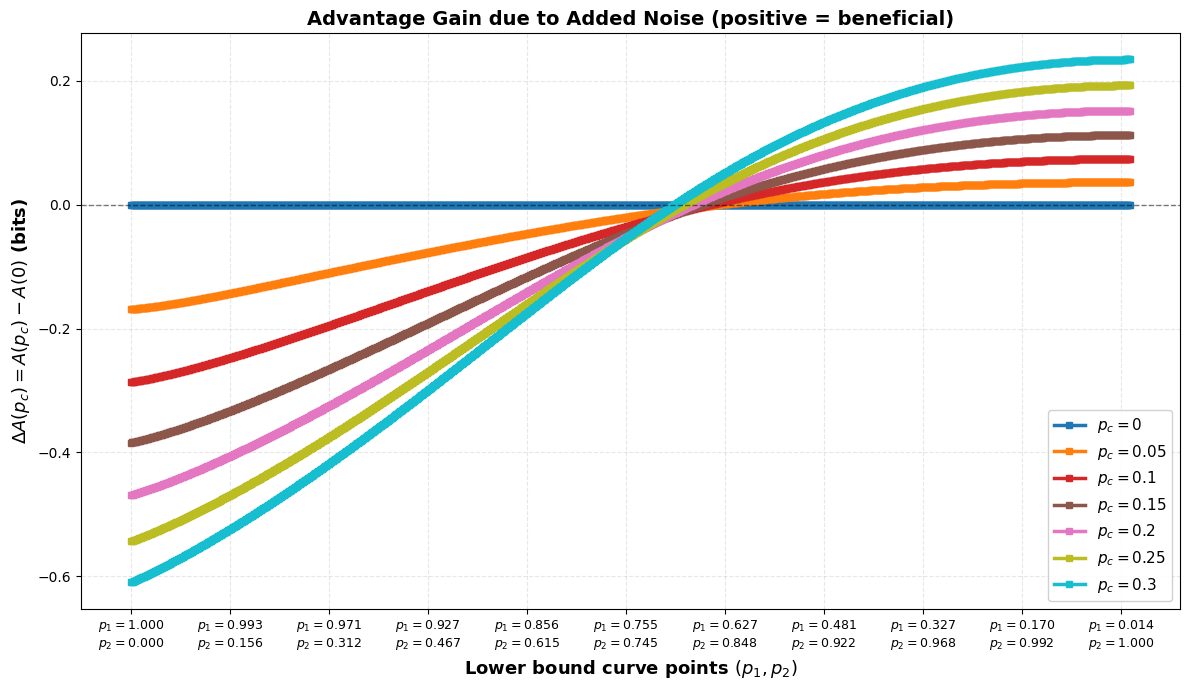

In [26]:
plt.figure(figsize=(12, 7))

colors_map = plt.cm.tab10(np.linspace(0, 1, len(pcs)))

x = np.arange(len(p2s))

for idx, pc in enumerate(pcs):
    gains = adv_gains[f"{pc}"]
    plt.plot(
        x,
        gains,
        linewidth=2.5,
        marker='s',
        markersize=4,
        color=colors_map[idx],
        label=fr"$p_c = {pc}$"
    )

plt.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)

# Two-line labels: p1 value above p2 value
xtick_labels = [
    rf"$p_1={p1:.3f}$" + "\n" + rf"$p_2={p2:.3f}$"
    for p1, p2 in zip(p1s, p2s)
]

step = 99  

plt.xticks(
    ticks=x[::step],
    labels=[
        rf"$p_1={p1:.3f}$" + "\n" + rf"$p_2={p2:.3f}$"
        for p1, p2 in zip(p1s[::step], p2s[::step])
    ],
    fontsize=9
)

plt.xlabel(r"Lower bound curve points $(p_1, p_2)$", fontsize=13, fontweight='bold')
plt.ylabel(r"$\Delta A(p_c) = A(p_c) - A(0)$ (bits)", fontsize=13, fontweight='bold')
plt.title(r"Advantage Gain due to Added Noise (positive = beneficial)", fontsize=14, fontweight='bold')

plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(loc='best', fontsize=11, framealpha=0.9)
plt.tight_layout()
plt.show()

## 5. Relation to the $11\%$ QBER reference

A commonly used reference in BB84 security discussions is the approximately $11\%$ QBER limit associated with the Shor–Preskill asymptotic security result under its assumptions.

Within the cloning model used here,

$$\alpha = \frac{1-(1-p_c)p_1}{2} = \text{QBER}$$

This allows the $11\%$ line to be placed directly on the leakage–disturbance curves. For each value of $p_c$, the code finds the sampled cloning-boundary point with the largest QBER still below $0.11$ and records the corresponding leakage and clone parameters.

This is a **comparison with the $11\%$ reference**, not a re-derivation of the Shor–Preskill bound.

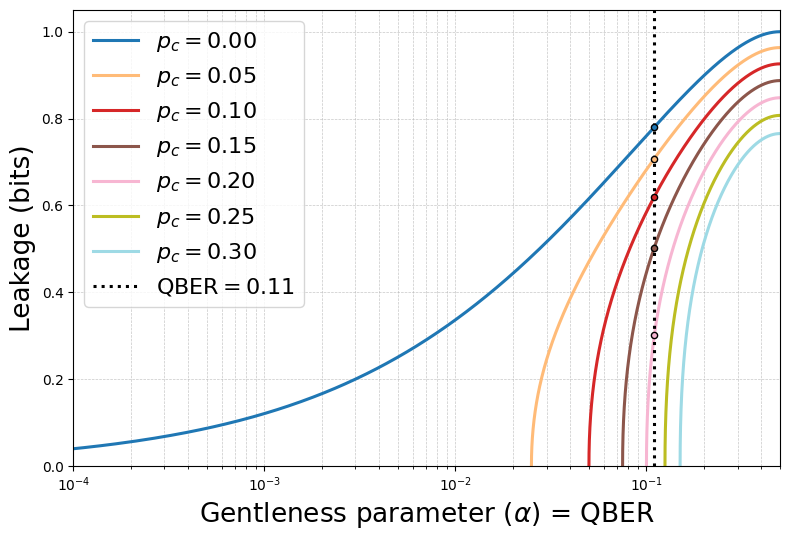

pc=0.00 | idx=473 | p1=0.780253 | p2=0.717797 | max QBER < 0.11 = 0.109873 | leakage = 0.780559
pc=0.05 | idx=433 | p1=0.821975 | p2=0.665836 | max QBER < 0.11 = 0.109562 | leakage = 0.707122
pc=0.10 | idx=383 | p1=0.867169 | p2=0.596089 | max QBER < 0.11 = 0.109774 | leakage = 0.619629
pc=0.15 | idx=312 | p1=0.918125 | p2=0.490400 | max QBER < 0.11 = 0.109797 | leakage = 0.502677
pc=0.20 | idx=184 | p1=0.975178 | p2=0.290279 | max QBER < 0.11 = 0.109929 | leakage = 0.301264
pc=0.25 | idx=None | p1=nan | p2=nan | max QBER < 0.11 = nan | leakage = nan
pc=0.30 | idx=None | p1=nan | p2=nan | max QBER < 0.11 = nan | leakage = nan


In [27]:
pcs = [0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3]
colors = plt.cm.tab20(np.linspace(0, 1, len(pcs)))

alpha_threshold = 0.11
plt.figure(figsize=(8, 5.5))

# Keep fixed copies of the cloning boundary. No array is modified in the loop.
p1s_base = np.asarray(p1s)
p2s_base = np.asarray(p2s)

threshold_results = []

for pc, color in zip(pcs, colors):
    alphas, leakages = compute_cloning_leakage_alpha(
        p1s_base,
        p2s_base,
        pc=pc
    )

    alphas = np.asarray(alphas)
    leakages = np.asarray(leakages)

    # Positive alpha values are required by the logarithmic x-axis.
    valid_mask = alphas > 0
    below_mask = valid_mask & (alphas < alpha_threshold)

    if np.any(below_mask):
        candidate_indices = np.where(below_mask)[0]
        idx_curve = candidate_indices[np.argmax(alphas[candidate_indices])]

        alpha_below = alphas[idx_curve]
        leakage_below = leakages[idx_curve]
        p1_below = p1s_base[idx_curve]
        p2_below = p2s_base[idx_curve]
    else:
        idx_curve = None
        alpha_below = np.nan
        leakage_below = np.nan
        p1_below = np.nan
        p2_below = np.nan

    threshold_results.append({
        "pc": pc,
        "idx_curve": idx_curve,
        "alpha_below_0.11": alpha_below,
        "leakage_at_alpha_below_0.11": leakage_below,
        "p1_below": p1_below,
        "p2_below": p2_below
    })

    # Sort only for plotting; preserve the original boundary indexing.
    plot_indices = np.where(valid_mask)[0]
    sorted_plot_indices = plot_indices[np.argsort(alphas[plot_indices])]

    plt.plot(
        alphas[sorted_plot_indices],
        leakages[sorted_plot_indices],
        linewidth=2.2,
        color=color,
        label=fr"$p_c={pc:.2f}$"
    )

    if idx_curve is not None:
        plt.scatter(
            alpha_below,
            leakage_below,
            s=20,
            marker="o",
            color=color,
            edgecolor="black",
            zorder=5
        )

plt.axvline(
    x=alpha_threshold,
    color="black",
    linestyle=":",
    linewidth=2.2,
    label=fr"$\mathrm{{QBER}}={alpha_threshold}$"
)

plt.xscale("log")
plt.xlim(1e-4, 0.5)
plt.ylim(0, 1.05)

plt.xlabel(r"Gentleness parameter ($\alpha$) = QBER", fontsize=19)
plt.ylabel("Leakage (bits)", fontsize=19)

plt.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.7)
plt.legend(fontsize=16)
plt.tight_layout()
plt.show()

for result in threshold_results:
    print(
        f"pc={result['pc']:.2f} | "
        f"idx={result['idx_curve']} | "
        f"p1={result['p1_below']:.6f} | "
        f"p2={result['p2_below']:.6f} | "
        f"max QBER < 0.11 = {result['alpha_below_0.11']:.6f} | "
        f"leakage = {result['leakage_at_alpha_below_0.11']:.6f}"
    )

### 5.1 Where does the $11\%$ point fall in the capacity–leakage comparison?

The same sampled points can be projected onto $\Delta_{\text{info}}$. This makes it possible to check whether satisfying the $11\%$ QBER reference also implies a positive capacity-minus-leakage comparison under the present cloning model.

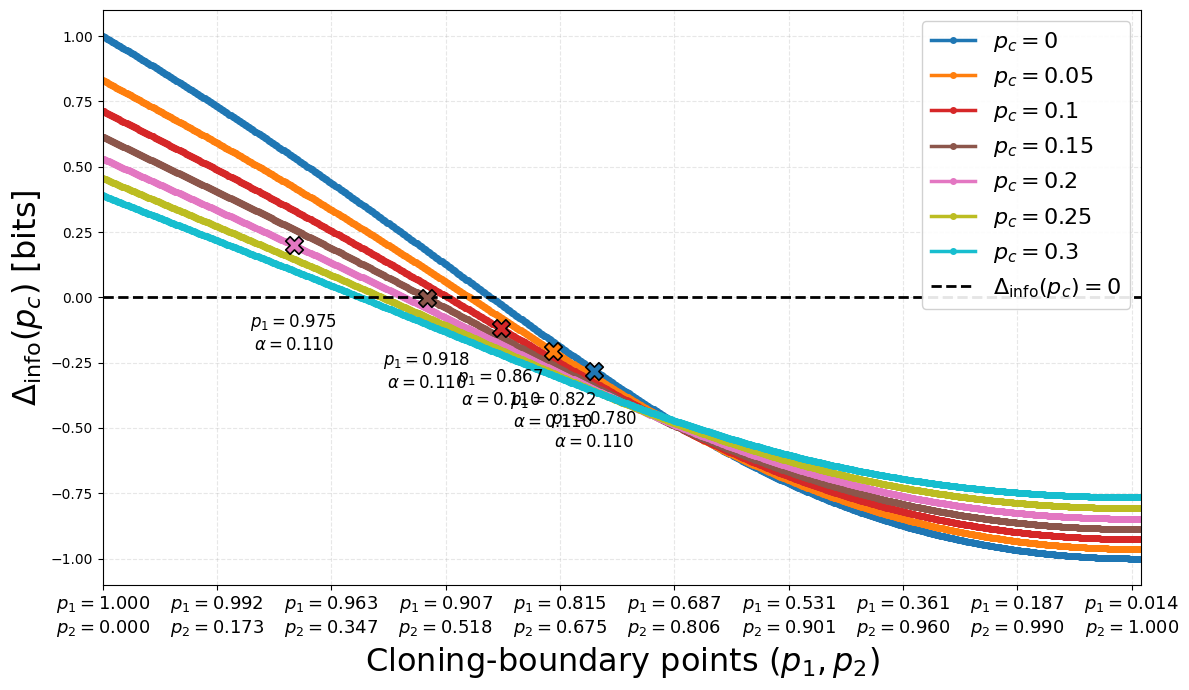

In [28]:
plt.figure(figsize=(12, 7))

colors_map = plt.cm.tab10(np.linspace(0, 1, len(pcs)))

common_len = min(
    len(p1s_base),
    len(p2s_base),
    *[len(np.asarray(inf_adv[f"{pc}"])) for pc in pcs]
)

x = np.arange(common_len)

# Fixed offsets avoid overlap without changing the data being displayed.
annotation_offsets = [
    (0, -55),
    (0, -55),
    (0, -55),
    (0, -65),
    (0, -75),
    (0, -85),
    (0, -95),
]

for idx, pc in enumerate(pcs):
    advantages = np.asarray(inf_adv[f"{pc}"])[:common_len]

    plt.plot(
        x,
        advantages,
        linewidth=2.5,
        marker='o',
        markersize=4,
        color=colors_map[idx],
        label=fr"$p_c = {pc}$"
    )

    result_pc = threshold_results[idx]
    idx_curve = result_pc["idx_curve"]

    if idx_curve is not None and idx_curve < common_len:
        advantage_at_threshold = advantages[idx_curve]

        plt.scatter(
            x[idx_curve],
            advantage_at_threshold,
            s=160,
            marker="X",
            color=colors_map[idx],
            edgecolor="black",
            linewidth=1.2,
            zorder=6
        )

        plt.annotate(
            rf"$p_1={result_pc['p1_below']:.3f}$"
            + "\n"
            + rf"$\alpha={result_pc['alpha_below_0.11']:.3f}$",
            xy=(x[idx_curve], advantage_at_threshold),
            xytext=annotation_offsets[idx],
            textcoords="offset points",
            ha="center",
            fontsize=12,
            fontweight='bold'
        )

step = 110
xtick_positions = x[::step]
xtick_labels = [
    rf"$p_1={p1:.3f}$" + "\n" + rf"$p_2={p2:.3f}$"
    for p1, p2 in zip(p1s_base[:common_len:step], p2s_base[:common_len:step])
]

plt.xticks(
    ticks=xtick_positions,
    labels=xtick_labels,
    fontsize=13,
    rotation=0
)

plt.axhline(
    y=0,
    color="black",
    linestyle="--",
    linewidth=2,
    label=r"$\Delta_{\mathrm{info}}(p_c)=0$"
)
plt.xlim(xmin=x[0], xmax=x[-1])

plt.xlabel(r"Cloning-boundary points $(p_1,p_2)$", fontsize=23)
plt.ylabel(r"$\Delta_{\mathrm{info}}(p_c)$ [bits]", fontsize=23)

plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(loc='best', fontsize=16, framealpha=0.9)
plt.tight_layout()
plt.show()

For low values of $p_c$, the point immediately below $11\%$ QBER can lie in the region where $\Delta_{\text{info}} < 0$. In other words, **the $11\%$ reference does not by itself guarantee a positive value of this particular capacity-minus-leakage diagnostic**.

This does not contradict the standard BB84 security threshold: the quantities and attack model used here are different from the secret-key-rate expression appearing in the Shor–Preskill proof. The result should therefore be read as a property of the leakage/cloning comparison developed in this thesis.

## 6. Model-specific QBER boundary from $\Delta_{\text{info}} = 0$

A final experiment asks a different question: along the optimal cloning boundary, at what sampled point does the diagnostic change sign?

For each $p_c$, the following code selects the point with the **smallest strictly positive** value of $\Delta_{\text{info}}$. Its QBER is used as a finite-grid estimate of the boundary between

$$\Delta_{\text{info}} > 0 \quad\text{and}\quad \Delta_{\text{info}} < 0$$

Because the cloning curve is sampled with a finite number of points, the reported value is an approximation whose precision depends on `num_points`. It should be interpreted only within this model and must not be presented as a universal replacement for the standard BB84 security threshold.

In [29]:
positive_advantage_results = []

for pc in pcs:
    advantages = np.asarray(inf_adv[f"{pc}"])[:common_len]
    mask_positive = advantages > 0

    if not np.any(mask_positive):
        positive_advantage_results.append({
            "pc": pc,
            "idx": None,
            "advantage": None,
            "p1": None,
            "p2": None,
        })
        continue

    positive_indices = np.where(mask_positive)[0]

    # Finite-grid point closest to the zero crossing from the positive side.
    idx_min_positive = positive_indices[
        np.argmin(advantages[positive_indices])
    ]

    positive_advantage_results.append({
        "pc": pc,
        "idx": idx_min_positive,
        "advantage": advantages[idx_min_positive],
        "p1": p1s_base[idx_min_positive],
        "p2": p2s_base[idx_min_positive],
    })

For each selected boundary point, we now recover Eve's leakage and the corresponding effective QBER,

$$L_E = \log_2\!\left[1 + (1 - p_c)p_2\right], \qquad \text{QBER} = \frac{1 - (1 - p_c)p_1}{2}$$

In [30]:
for r in positive_advantage_results:

    if r["idx"] is None:
        r["leakage"] = None
        r["BER"] = None
        continue

    pc = r["pc"]
    p1 = r["p1"]
    p2 = r["p2"]

    r["leakage"] = np.log2(1 + (1 - pc) * p2)
    r["BER"] = (1 - (1 - pc) * p1) / 2

In [31]:
for r in positive_advantage_results:
    print(f"pc = {r['pc']}")

    if r["idx"] is None:
        print("  No positive information advantage found")
    else:
        print(f"  idx       = {r['idx']}")
        print(f"  p1        = {r['p1']:.6f}")
        print(f"  p2        = {r['p2']:.6f}")
        print(f"  advantage = {r['advantage']:.6f}")
        print(f"  leakage   = {r['leakage']:.6f}")
        print(f"  BER       = {r['BER']:.6f}")

    print()

pc = 0
  idx       = 373
  p1        = 0.875272
  p2        = 0.581609
  advantage = 0.001849
  leakage   = 0.661393
  BER       = 0.062364

pc = 0.05
  idx       = 353
  p1        = 0.890554
  p2        = 0.552206
  advantage = 0.000102
  leakage   = 0.608427
  BER       = 0.076987

pc = 0.1
  idx       = 332
  p1        = 0.905296
  p2        = 0.520777
  advantage = 0.000317
  leakage   = 0.554539
  BER       = 0.092617

pc = 0.15
  idx       = 311
  p1        = 0.918737
  p2        = 0.488872
  advantage = 0.000129
  leakage   = 0.501353
  BER       = 0.109537

pc = 0.2
  idx       = 289
  p1        = 0.931470
  p2        = 0.455034
  advantage = 0.001830
  leakage   = 0.447872
  BER       = 0.127412

pc = 0.25
  idx       = 268
  p1        = 0.942392
  p2        = 0.422424
  advantage = 0.001671
  leakage   = 0.397056
  BER       = 0.146603

pc = 0.3
  idx       = 248
  p1        = 0.951726
  p2        = 0.391153
  advantage = 0.000299
  leakage   = 0.349147
  BER       = 0.166896

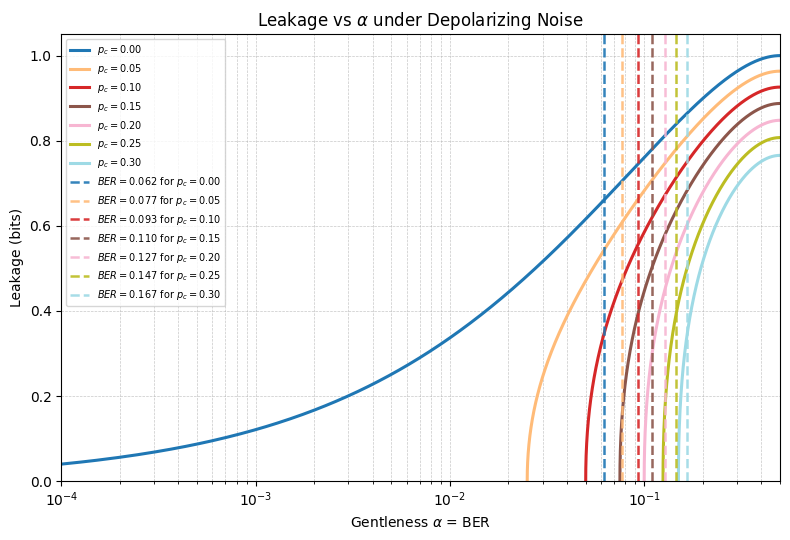

In [32]:
# Depolarizing noise
pcs = [0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3]

colors = plt.cm.tab20(np.linspace(0, 1, len(pcs)))
colors_by_pc = {pc: color for pc, color in zip(pcs, colors)}

plt.figure(figsize=(8, 5.5))

p1s_base = np.asarray(p1s)
p2s_base = np.asarray(p2s)

for pc in pcs:

    color = colors_by_pc[pc]

    alphas, leakages = compute_cloning_leakage_alpha(
        p1s_base,
        p2s_base,
        pc=pc
    )

    alphas = np.asarray(alphas)
    leakages = np.asarray(leakages)

    # Valid mask to avoid log(0)
    valid_mask = alphas > 0

    # Sort only for plotting
    plot_indices = np.where(valid_mask)[0]
    sorted_plot_indices = plot_indices[np.argsort(alphas[plot_indices])]

    plt.plot(
        alphas[sorted_plot_indices],
        leakages[sorted_plot_indices],
        linewidth=2.2,
        color=color,
        label=fr"$p_c={pc:.2f}$"
    )

# Vertical BER lines from positive_advantage_results
for r in positive_advantage_results:

    if r["idx"] is not None:

        pc = r["pc"]
        BER = r["BER"]

        color = colors_by_pc[pc]

        plt.axvline(
            x=BER,
            color=color,
            linestyle="--",
            linewidth=1.8,
            alpha=0.9,
            label=fr"$BER={BER:.3f}$ for $p_c={pc:.2f}$"
        )

plt.xscale("log")
plt.xlim(1e-4, 1)
plt.ylim(0, 1.05)

plt.xlabel(r"Gentleness $\alpha$ = BER")
plt.ylabel("Leakage (bits)")
plt.title(r"Leakage vs $\alpha$ under Depolarizing Noise")
plt.xlim(0.0001,0.5)

plt.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.7)
plt.legend(fontsize=7)
plt.tight_layout()
plt.show()

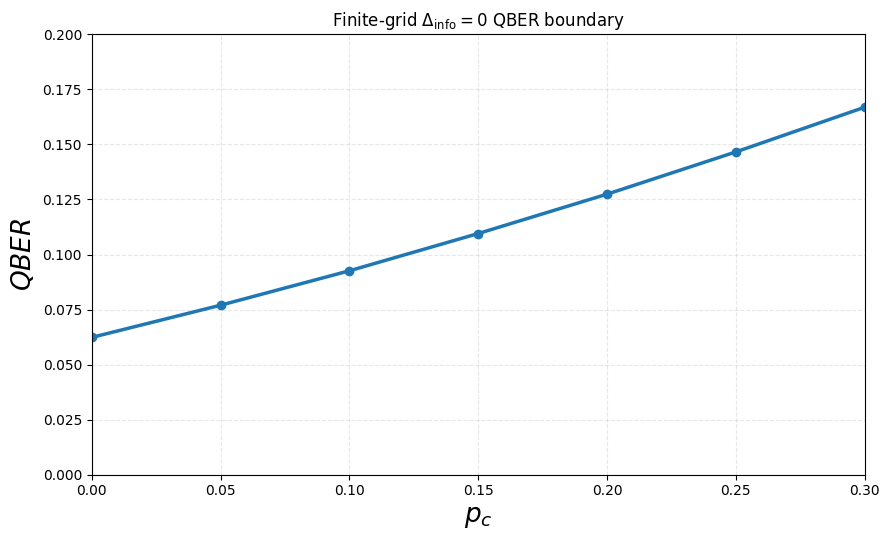

In [33]:
pcs_plot = []
bers_plot = []

for r in positive_advantage_results:
    if r["BER"] is not None:
        pcs_plot.append(r["pc"])
        bers_plot.append(r["BER"])

plt.figure(figsize=(9, 5.5))

plt.plot(
    pcs_plot,
    bers_plot,
    linewidth=2.5,
    marker="o",
    markersize=6
)

plt.xlabel(r"$p_c$", fontsize=19)
plt.ylabel(r"$QBER$", fontsize=19)
plt.ylim(0, 0.2)
plt.xlim(0., 0.3)


plt.title(r"Finite-grid $\Delta_{\mathrm{info}}=0$ QBER boundary")
plt.grid(True, alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()

## Conclusion

This notebook develops the final leakage/cloning analysis used in the Master's Thesis.

The main steps were:

* the physically admissible trade-off between Bob's and Eve's copies was represented through the optimal asymmetric cloning-region boundary;
* each cloning point was mapped to a Bob-side disturbance/QBER and an Eve-side leakage value;
* additional depolarizing noise was incorporated through the effective clone parameters $p_i^{\text{eff}} = (1 - p_c)p_i$;
* the sifted Alice–Bob link was modeled as a BSC and compared with Eve's leakage through the diagnostic quantity

$$\Delta_{\text{info}} = C_{AB} - L_E;$$

* the standard $11\%$ QBER reference was projected onto the cloning/leakage curves; and
* a model-specific finite-grid QBER boundary was extracted from the condition $\Delta_{\text{info}} > 0$.

For $p_c = 0$, the sampled zero-crossing analysis places this model-specific boundary at approximately **6.2% QBER**. As $p_c$ increases in the adopted symmetric depolarizing model, the corresponding boundary shifts to larger QBER values. The numerical value is sensitive to the modeling assumptions and to the finite sampling of the cloning boundary.

The central conclusion is therefore **not** that the conventional BB84 threshold should be replaced by a new universal number. Rather, the study shows that a leakage metric combined with the asymmetric cloning region can impose a different and more restrictive information-balance condition than a conventional QBER-only comparison. This distinction is precisely what motivated the final thesis analysis.

Together with the two preceding notebooks, the repository documents the progression from basic leakage metrics, through exploratory POVM constructions, to the cloning-region framework used for the final study.